# SAE Feature Recovery: Decomposing Superposed Representations

An autoencoder compresses N features into a smaller hidden space,
creating superposed representations where features overlap. A Sparse
Autoencoder (SAE) attempts to reverse this -- decomposing the hidden
activations back into individual feature directions.

This example demonstrates the full SAE pipeline in occhio:
1. Train an autoencoder that compresses features into superposition
2. Train SAEs on the autoencoder's latent space
3. Evaluate how well the SAEs recover the ground-truth features
4. Sweep over the L1 sparsity coefficient to reveal the
   precision-recall tradeoff
5. Compare SAE recovery across different data distributions
6. Monitor training convergence with loss snapshots

Requires: `pip install occhio` (or editable install from this repo).

In [1]:
# -- Imports -----------------------------------------------------------------

import torch
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig

from occhio import ToyModel, SAEEntry
from occhio.autoencoders import TiedLinearRelu
from occhio.distributions import SparseUniform, HierarchicalPairs
from occhio.visualization import SAEFeatureSimilarityPlot

pio.renderers.default = "png"
torch.manual_seed(0)

## 1. Train an Autoencoder in the Superposition Regime

We use the standard Toy Models of Superposition setup: 50 features
compressed into 15 hidden dimensions. With 1% sparsity (p_active=0.01),
most features are inactive in any given sample, and the network
exploits superposition to represent all 50 features using only 15
dimensions.

The SAE's job will be to untangle this superposed representation.

In [2]:
N_FEATURES = 50
N_HIDDEN = 15
P_ACTIVE = 0.01
DEVICE = "cpu"

dist = SparseUniform(n_features=N_FEATURES, p_active=P_ACTIVE, device=DEVICE)
ae = TiedLinearRelu(n_features=N_FEATURES, n_hidden=N_HIDDEN, device=DEVICE)
model = ToyModel(dist, ae, device=DEVICE)

ae_losses, _ = model.fit(
    n_epochs=25_000,
    batch_size=1024,
    learning_rate=3e-4,
)

print(f"AE: {N_FEATURES} features -> {N_HIDDEN} hidden dims")
print(f"Sparsity: p_active={P_ACTIVE} (expected L0={N_FEATURES * P_ACTIVE})")
print(f"Superposition metric (rho_mm): {model.superposition.item():.4f}")
print(f"Final AE loss: {ae_losses[-1]:.6f}")

AE: 50 features -> 15 hidden dims
Sparsity: p_active=0.01 (expected L0=0.5)
Superposition metric (rho_mm): 0.5468
Final AE loss: 0.008958


## 2. Train a Single SAE

`model.train_saes()` trains SAEs on the autoencoder's hidden
activations using the sae-lens library under the hood. Each SAE is
specified as an `SAEEntry` wrapping a sae-lens `TrainingSAE` object.

Key sizing: the SAE's input dimension `d_in` must match the AE's
hidden dimension (`n_hidden`), and `d_sae` is the SAE dictionary
size -- roughly 0.85x the number of ground-truth features.

In [3]:
D_SAE = 42  # ~0.85 * N_FEATURES, undercomplete relative to true features
SAE_TRAINING_SAMPLES = 1_000_000
SAE_BATCH_SIZE = 1024

sae_entry = SAEEntry(
    sae=StandardTrainingSAE(
        StandardTrainingSAEConfig(
            d_in=N_HIDDEN,
            d_sae=D_SAE,
            l1_coefficient=0.3,
        )
    ),
    type="Standard",
    params={"l1_coefficient": 0.3},
)

model.train_saes(
    [sae_entry],
    training_samples=SAE_TRAINING_SAMPLES,
    batch_size=SAE_BATCH_SIZE,
)

print(f"Trained SAE: {N_HIDDEN} -> {D_SAE} latents")
print(f"SAE labels: {list(model.saes.keys())}")

Trained SAE: 15 -> 42 latents
SAE labels: ['Standard_0']


## 3. Evaluate Against Ground Truth

`model.evaluate_saes()` compares the SAE's decoder directions against
the autoencoder's true feature embeddings. It computes:
- **F1, precision, recall**: treating each SAE latent as a binary
  feature detector
- **MCC**: mean correlation between SAE decoder and ground-truth
  feature vectors
- **Explained variance**: how well the SAE reconstruction preserves
  the hidden activations
- **Uniqueness**: fraction of SAE latents tracking distinct features
- **Shrinkage**: ratio of SAE output norm to input norm (L1 penalty
  tends to shrink activations)

In [4]:
results = model.evaluate_saes()
result = results["Standard_0"]

print("=== SAE Evaluation Results ===")
print(f"  F1 score:          {result.classification.f1_score:.3f}")
print(f"  Precision:         {result.classification.precision:.3f}")
print(f"  Recall:            {result.classification.recall:.3f}")
print(f"  MCC:               {result.mcc:.3f}")
print(f"  Explained var:     {result.explained_variance:.3f}")
print(f"  Uniqueness:        {result.uniqueness:.3f}")
print(f"  Shrinkage:         {result.shrinkage:.3f}")
print(f"  SAE L0:            {result.sae_l0:.2f}")
print(f"  True L0:           {result.true_l0:.2f}")
print(f"  Dead latents:      {result.dead_latents}")

=== SAE Evaluation Results ===
  F1 score:          0.126
  Precision:         0.073
  Recall:            0.454
  MCC:               0.673
  Explained var:     0.694
  Uniqueness:        0.690
  Shrinkage:         0.391
  SAE L0:            2.67
  True L0:           0.51
  Dead latents:      0


### Decoder--Feature Alignment Heatmap

Each SAE latent's decoder vector should align with exactly one
ground-truth feature. The cosine similarity matrix reveals how
cleanly the SAE has separated the features. Ideal recovery shows
one bright cell per column (each feature matched by one latent).

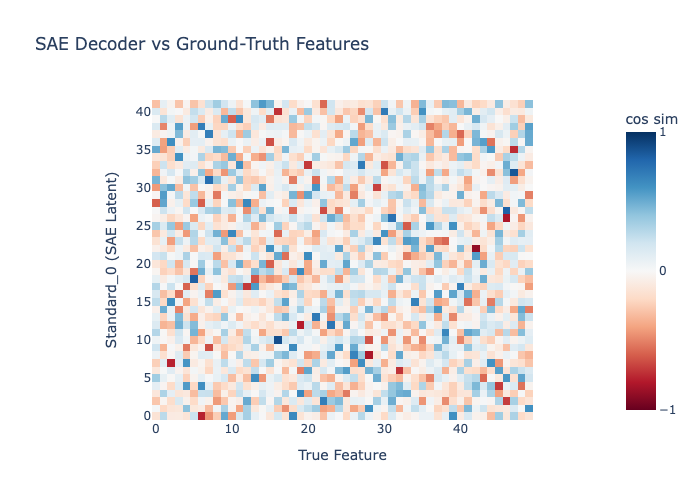

In [5]:
# occhio's SAEFeatureSimilarityPlot computes cosine similarity between
# each SAE decoder vector and each ground-truth feature embedding.
# reorder=False because the Hungarian reordering assumes n_latents >= n_features;
# with our undercomplete SAE (42 latents < 50 features), we skip it.
fig = SAEFeatureSimilarityPlot(sae_label="Standard_0", reorder=False)(
    model, height=500, width=700
)
fig.update_layout(title="SAE Decoder vs Ground-Truth Features")
fig.show()

## 4. L1 Coefficient Sweep: The Sparsity Tradeoff

The L1 penalty is the main knob controlling SAE sparsity. Sweeping
over L1 values reveals a fundamental tradeoff:
- **Too little L1**: latents fire on multiple features (low precision)
- **Too much L1**: latents shrink to zero, features are lost (low recall)
- **Sweet spot**: best balance of precision and recall (look for
  peak F1 and MCC)

We train fresh SAEs at each L1 value on the same autoencoder.

In [6]:
l1_values = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

# Clear any previously trained SAEs
model.saes = {}

sae_entries = [
    SAEEntry(
        sae=StandardTrainingSAE(
            StandardTrainingSAEConfig(
                d_in=N_HIDDEN,
                d_sae=D_SAE,
                l1_coefficient=l1,
            )
        ),
        type="Standard",
        params={"l1_coefficient": l1},
        label=f"l1={l1}",
    )
    for l1 in l1_values
]

model.train_saes(
    sae_entries,
    training_samples=SAE_TRAINING_SAMPLES,
    batch_size=SAE_BATCH_SIZE,
    verbose=True,
)
sweep_results = model.evaluate_saes(verbose=True)

SAEs:   0%|          | 0/9 [00:00<?, ?SAE/s]

SAEs:   0%|          | 0/9 [00:00<?, ?SAE/s]

In [7]:
# -- Collect metrics for plotting --
sweep_f1 = [sweep_results[f"l1={l1}"].classification.f1_score for l1 in l1_values]
sweep_prec = [sweep_results[f"l1={l1}"].classification.precision for l1 in l1_values]
sweep_rec = [sweep_results[f"l1={l1}"].classification.recall for l1 in l1_values]
sweep_mcc = [sweep_results[f"l1={l1}"].mcc for l1 in l1_values]
sweep_l0 = [sweep_results[f"l1={l1}"].sae_l0 for l1 in l1_values]
sweep_dead = [sweep_results[f"l1={l1}"].dead_latents for l1 in l1_values]

print(
    f"{'L1':>6}  {'F1':>6}  {'Prec':>6}  {'Rec':>6}  {'MCC':>6}  {'L0':>6}  {'Dead':>5}"
)
print("-" * 55)
for i, l1 in enumerate(l1_values):
    print(
        f"{l1:6.2f}  {sweep_f1[i]:6.3f}  {sweep_prec[i]:6.3f}  "
        f"{sweep_rec[i]:6.3f}  {sweep_mcc[i]:6.3f}  {sweep_l0[i]:6.2f}  "
        f"{sweep_dead[i]:5d}"
    )

    L1      F1    Prec     Rec     MCC      L0   Dead
-------------------------------------------------------
  0.05   0.061   0.032   0.560   0.599    7.18      0
  0.10   0.054   0.029   0.416   0.625    6.00      0
  0.20   0.086   0.048   0.469   0.629    4.04      0
  0.30   0.146   0.085   0.529   0.665    2.63      0
  0.50   0.438   0.311   0.771   0.810    1.09      0
  0.70   0.712   0.652   0.793   0.895    0.52      0
  1.00   0.794   0.808   0.783   0.865    0.41      0
  1.50   0.545   0.747   0.467   0.769    0.22      0
  2.00   0.028   0.414   0.015   0.668    0.01      0


### Classification Metrics vs L1

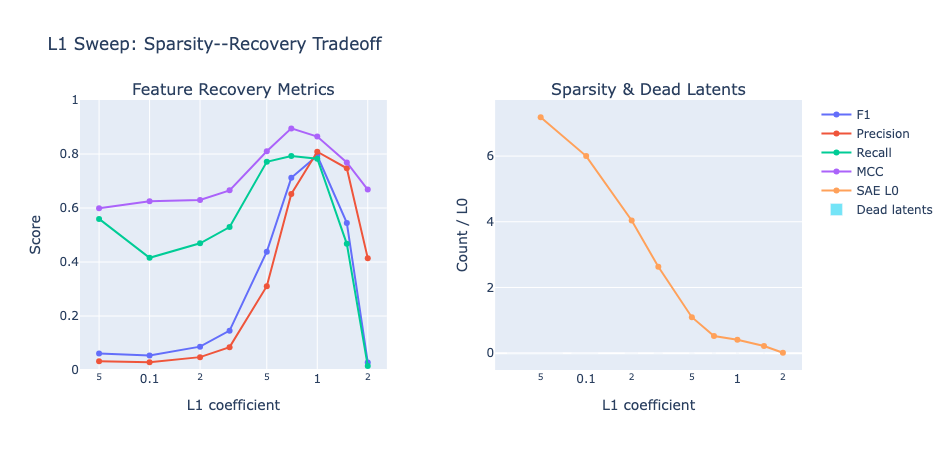

In [8]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Feature Recovery Metrics", "Sparsity & Dead Latents"),
    horizontal_spacing=0.15,
)

# Left panel: F1, precision, recall, MCC
for name, values, color in [
    ("F1", sweep_f1, "#636EFA"),
    ("Precision", sweep_prec, "#EF553B"),
    ("Recall", sweep_rec, "#00CC96"),
    ("MCC", sweep_mcc, "#AB63FA"),
]:
    fig.add_trace(
        go.Scatter(
            x=l1_values,
            y=values,
            mode="lines+markers",
            name=name,
            line=dict(color=color),
        ),
        row=1,
        col=1,
    )

# Right panel: SAE L0 and dead latent count
fig.add_trace(
    go.Scatter(
        x=l1_values,
        y=sweep_l0,
        mode="lines+markers",
        name="SAE L0",
        line=dict(color="#FFA15A"),
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(
        x=l1_values,
        y=sweep_dead,
        name="Dead latents",
        marker_color="#19D3F3",
        opacity=0.6,
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="L1 coefficient", type="log", row=1, col=1)
fig.update_xaxes(title_text="L1 coefficient", type="log", row=1, col=2)
fig.update_yaxes(title_text="Score", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="Count / L0", row=1, col=2)
fig.update_layout(
    title="L1 Sweep: Sparsity--Recovery Tradeoff",
    height=450,
    width=950,
)
fig.show()

## 5. Distribution Comparison: How Does Correlation Affect Feature Recovery?

SAEs assume features are independent and sparse. What happens when
ground-truth features are correlated? HierarchicalPairs creates
parent-child feature pairs where the child only fires when the parent
does.

We train fresh autoencoders on both distributions, then train SAEs
on each and compare.

In [9]:
distributions = {
    "SparseUniform": SparseUniform(
        n_features=N_FEATURES, p_active=P_ACTIVE, device=DEVICE
    ),
    "HierarchicalPairs": HierarchicalPairs(
        n_features=N_FEATURES,
        p_active=P_ACTIVE,
        p_follow=0.7,
        device=DEVICE,
    ),
}

# A moderate L1 value for fair comparison
L1_COMPARE = 0.3

dist_results = {}

for dist_name, distribution in distributions.items():
    torch.manual_seed(0)
    ae_i = TiedLinearRelu(n_features=N_FEATURES, n_hidden=N_HIDDEN, device=DEVICE)
    model_i = ToyModel(distribution, ae_i, device=DEVICE)
    losses_i, _ = model_i.fit(
        n_epochs=25_000,
        batch_size=1024,
        learning_rate=3e-4,
    )

    sae_i = SAEEntry(
        sae=StandardTrainingSAE(
            StandardTrainingSAEConfig(
                d_in=N_HIDDEN,
                d_sae=D_SAE,
                l1_coefficient=L1_COMPARE,
            )
        ),
        type="Standard",
        params={"l1_coefficient": L1_COMPARE},
    )
    model_i.train_saes(
        [sae_i],
        training_samples=SAE_TRAINING_SAMPLES,
        batch_size=SAE_BATCH_SIZE,
    )
    eval_i = model_i.evaluate_saes()
    res = eval_i["Standard_0"]

    dist_results[dist_name] = {
        "model": model_i,
        "ae_loss": losses_i[-1],
        "superposition": model_i.superposition.item(),
        "f1": res.classification.f1_score,
        "precision": res.classification.precision,
        "recall": res.classification.recall,
        "mcc": res.mcc,
        "explained_var": res.explained_variance,
        "uniqueness": res.uniqueness,
        "sae_l0": res.sae_l0,
        "dead_latents": res.dead_latents,
    }

    print(f"\n--- {dist_name} ---")
    print(f"  AE loss:       {losses_i[-1]:.6f}")
    print(f"  Superposition: {model_i.superposition.item():.4f}")
    print(f"  SAE F1:        {res.classification.f1_score:.3f}")
    print(f"  SAE MCC:       {res.mcc:.3f}")
    print(f"  SAE L0:        {res.sae_l0:.2f}")


--- SparseUniform ---
  AE loss:       0.008958
  Superposition: 0.5468
  SAE F1:        0.126
  SAE MCC:       0.673
  SAE L0:        2.67



--- HierarchicalPairs ---
  AE loss:       0.005579
  Superposition: 0.6053
  SAE F1:        0.186
  SAE MCC:       0.650
  SAE L0:        1.91


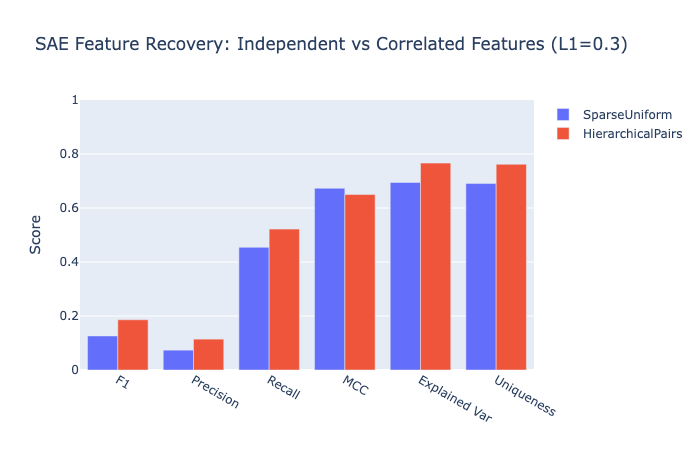

In [10]:
# -- Side-by-side comparison --

metrics = ["f1", "precision", "recall", "mcc", "explained_var", "uniqueness"]
metric_labels = [
    "F1",
    "Precision",
    "Recall",
    "MCC",
    "Explained Var",
    "Uniqueness",
]

fig = go.Figure()
for dist_name, color in [
    ("SparseUniform", "#636EFA"),
    ("HierarchicalPairs", "#EF553B"),
]:
    values = [dist_results[dist_name][m] for m in metrics]
    fig.add_trace(
        go.Bar(
            x=metric_labels,
            y=values,
            name=dist_name,
            marker_color=color,
        )
    )

fig.update_layout(
    title=(
        f"SAE Feature Recovery: Independent vs Correlated Features (L1={L1_COMPARE})"
    ),
    yaxis_title="Score",
    yaxis_range=[0, 1],
    barmode="group",
    height=450,
    width=700,
)
fig.show()

## 6. Training Loss Curves

The `n_loss_snapshots` parameter records the SAE loss at evenly
spaced intervals during training. This lets us verify convergence
without adding much overhead.

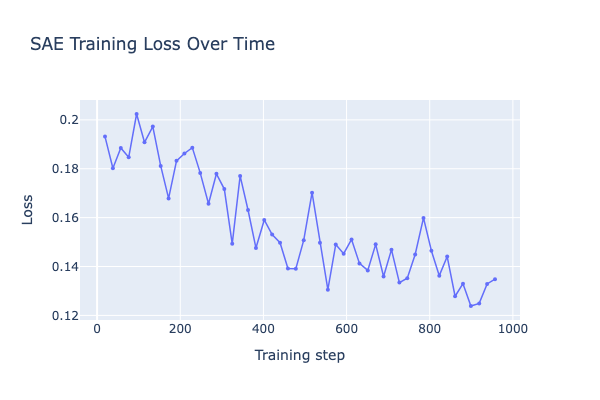

In [11]:
torch.manual_seed(0)
ae_lc = TiedLinearRelu(n_features=N_FEATURES, n_hidden=N_HIDDEN, device=DEVICE)
model_lc = ToyModel(dist, ae_lc, device=DEVICE)
model_lc.fit(
    n_epochs=25_000,
    batch_size=1024,
    learning_rate=3e-4,
)

sae_lc = SAEEntry(
    sae=StandardTrainingSAE(
        StandardTrainingSAEConfig(
            d_in=N_HIDDEN,
            d_sae=D_SAE,
            l1_coefficient=0.3,
        )
    ),
    type="Standard",
    params={"l1_coefficient": 0.3},
)
model_lc.train_saes(
    [sae_lc],
    training_samples=SAE_TRAINING_SAMPLES,
    batch_size=SAE_BATCH_SIZE,
    n_loss_snapshots=50,
)

loss_snapshots = model_lc.saes["Standard_0"].losses
assert loss_snapshots is not None, "losses should be recorded with n_loss_snapshots"
steps = [s for s, _ in loss_snapshots]
losses = [l for _, l in loss_snapshots]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=steps,
        y=losses,
        mode="lines+markers",
        marker=dict(size=4),
        line=dict(width=1.5),
        name="SAE loss",
    )
)
fig.update_layout(
    title="SAE Training Loss Over Time",
    xaxis_title="Training step",
    yaxis_title="Loss",
    height=400,
    width=600,
)
fig.show()

## Summary

This example covered the full SAE feature recovery workflow:

1. **Train an autoencoder** that compresses 50 features into 15
   dimensions using superposition
2. **Train SAEs** via `model.train_saes()` using sae-lens under
   the hood
3. **Evaluate** with `model.evaluate_saes()` to get F1, precision,
   recall, MCC, explained variance, and more
4. **Sweep the L1 coefficient** to find the precision-recall sweet
   spot
5. **Compare distributions** -- feature correlation
   (HierarchicalPairs) changes SAE recovery dynamics compared to
   independent features (SparseUniform)
6. **Monitor training** with `n_loss_snapshots` for convergence
   checks

Key API pattern:
```python
model.train_saes(
    [SAEEntry(sae=TrainingSAE(...), type="Standard", params={...})],
    training_samples=1_000_000,
)
results = model.evaluate_saes()
```